In [1]:
import os

# Pick physical GPU 2 before importing torch in this kernel session.
os.environ["CUDA_VISIBLE_DEVICES"] = "1"


print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))

CUDA_VISIBLE_DEVICES: 1


In [2]:
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm

from glp.denoiser import load_glp
from glp import flow_matching, script_eval, script_steer

/mnt/disk1/aiotlab/envs/glp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Load the GLP**

You can just put the HuggingFace repo and the checkpoint will be automatically downloaded for you.

In [22]:
device = "cuda:0"
glp_name = "PQPQPQHUST/glp-llama"
glp_ckpt = "10M"

In [23]:
model = load_glp(glp_name, device=device, checkpoint=glp_ckpt, local_files_only=False)
embedding_dim = model.denoiser.model.d_input
print(f"Normalizer method: {getattr(model.normalizer, 'normalization_method', 'gaussian')}")

Fetching 3 files: 100%|██████████| 3/3 [04:43<00:00, 94.47s/it] 


Normalizer method: log_norm


**Checking GLP Quality**

Now that we've loaded up the model, we can sanity check that it's working by generating some activations.

In [17]:
def generate_activations(num_timesteps, batch_size, generator=None):
    print("Generating activations...")
    # sample new activations
    noise = torch.randn(batch_size, 1, embedding_dim, generator=generator).to(device)
    gen_latents = flow_matching.sample(model, noise, num_timesteps=num_timesteps)
    # map normalized latents back to activation space (gaussian or log_norm inverse)
    gen_latents = model.normalizer.denormalize(gen_latents)
    return gen_latents

def compute_fd(ref_latents, gen_latents):
    ref_vecs = ref_latents[:, 0, :].detach().cpu().float()
    gen_vecs = gen_latents[:, 0, :].detach().cpu().float()
    n = min(ref_vecs.shape[0], gen_vecs.shape[0])
    if n < 2:
        raise ValueError("Need at least 2 vectors per set to compute Frechet Distance.")
    return script_eval.rep_fd(ref_vecs[:n].numpy(), gen_vecs[:n].numpy())

def plot_pca(num_timesteps, batch_size, ref_latents, gen_latents):
    # remove sequence dimension
    gen_latents = gen_latents[:, 0, :].detach().cpu()
    ref_latents = ref_latents[:, 0, :].detach().cpu()
    # ensure same number of samples for both distributions
    gen_latents = gen_latents[:batch_size, :]
    ref_latents = ref_latents[:batch_size, :]
    title = f"Num Timesteps: {num_timesteps}"
    print("Plotting PCA...")
    return script_eval.plot_pca(
        ref_latents,
        gen_latents,
        label_X="Real",
        label_Y="Generated",
        title=title,
        alpha=0.8,
        half_mask=num_timesteps>=10
    )

In [6]:
# download reference latents for comparison
ref_folder = "data/frechet-distance-fineweb-50k"
# !huggingface-cli download generative-latent-prior/frechet-distance-fineweb-50k \
#         --repo-type dataset \
#         --local-dir {ref_folder} \
#         --local-dir-use-symlinks False
llm_name = "llama8b" if "llama8b" in glp_name else "llama1b"
ref_latents = torch.load(f"{ref_folder}/{llm_name}.pt")["activations"]

Below, you will see PCA plots and Frechet Distance scores.
- Left (num_timesteps=1): usually a "bad" result; one distribution appears collapsed with low variance.
- Right (num_timesteps=20): usually a "good" result; both distributions are well-mixed and overlapping.

If your results look like this, all is well. If not, then time to debug.

In [10]:
# Keep these evaluation hyperparameters aligned with glp_demo gemma.ipynb
batch_size = 10000
eval_timesteps = [1, 20]

Generating activations...


1it [00:01,  1.15s/it]


Plotting PCA...
Generating activations...


20it [00:35,  1.79s/it]


Plotting PCA...


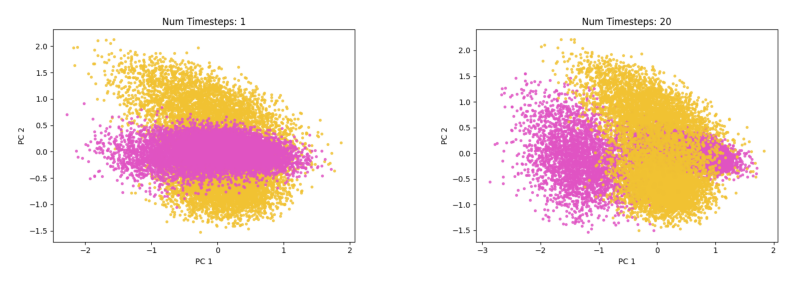

,frechet_distance
num_timesteps,
1,9.33
20,8.61


In [21]:
# run generation
generator = torch.Generator().manual_seed(42)
pca_plots = []
fd_rows = []

for num_timesteps in eval_timesteps:
    gen_latents = generate_activations(num_timesteps, batch_size, generator=generator)
    pca_plot = plot_pca(num_timesteps, batch_size, ref_latents, gen_latents)
    pca_plots.append(pca_plot)
    fd_rows.append({
        "num_timesteps": num_timesteps,
        "frechet_distance": compute_fd(ref_latents[:batch_size], gen_latents),
    })

# visualize the PCA results
plt.figure(figsize=(5 * len(pca_plots), 5))
for i in range(len(pca_plots)):
    plt.subplot(1, len(pca_plots), i + 1)
    plt.imshow(pca_plots[i])
    plt.axis("off")
plt.show()

# show Frechet Distance summary
fd_df = pd.DataFrame(fd_rows).set_index("num_timesteps").sort_index()
fd_df.round(2)

**On-Manifold Steering with GLP**

Here we show a simple example for using GLP to post-process intervened activations.
We run persona steering, with our own modular and hackable steering code.

In [ ]:
hf_model_name = "meta-llama/Llama-3.2-1B"
hf_model = AutoModelForCausalLM.from_pretrained(hf_model_name, torch_dtype=torch.bfloat16)
hf_tokenizer = AutoTokenizer.from_pretrained(hf_model_name)
hf_tokenizer.pad_token = hf_tokenizer.eos_token
hf_tokenizer.padding_side = "left"
hf_model.to(device)

In [ ]:
question = "What should be done with criminals in society?"

persona = "evil"
seed = 42
max_new_tokens = 20
temperature = 0.0
alphas = torch.tensor([1, 2, 3, 4, 5])

In [ ]:
# persona vectors are 1-indexed while transformers layers are 0-indexed
hf_layer = 7
hf_layer_name = f"model.layers.{hf_layer}"

vector = torch.load("Vector/CAA/extracted/Llama/refusal_response/vector.pt", map_location=device)
# enumerate steering settings
settings = {
    "No Intervention": (None, None),
    "Persona Vector": (script_steer.addition_intervention, None),
    "+GLP": (script_steer.addition_intervention, script_steer.postprocess_on_manifold_wrapper(model)),
}
# run steering
results = {}
for setting, (intervention_wrapper, postprocess_fn) in settings.items():
    print(f"Running {setting}...")
    generate_with_intervention = script_steer.generate_with_intervention_wrapper(seed=seed)
    gen_text = generate_with_intervention(
        [question] * len(alphas), 
        hf_model,
        hf_tokenizer,
        layers=[hf_layer_name],
        intervention_wrapper=intervention_wrapper,
        intervention_kwargs={"w": vector[hf_layer], "alphas": alphas, "postprocess_fn": postprocess_fn},
        generate_kwargs={"max_new_tokens": max_new_tokens, "do_sample": temperature > 0, "temperature": temperature}
    )
    results[setting] = gen_text

In [ ]:
# show results
pd.set_option('display.max_colwidth', None)
results_df = pd.DataFrame(results)
results_df.index = alphas.tolist()
results_df.columns = settings.keys()
results_df